<a href="https://colab.research.google.com/github/femas66/PCVK_Ganjil_2026/blob/main/M1_D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1_D2 — Pengenalan Python untuk Membaca dan Menampilkan Image

Pengenalan macam-macam library (Numpy, pandas, cv2, skimage, PIL, matplotlib).

### Langkah 1 — Import Library

In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
try:
    from google.colab.patches import cv2_imshow  # hanya ada di Google Colab
except ImportError:
    import matplotlib.pyplot as _plt
    def cv2_imshow(img):
        # fallback untuk dijalankan di luar Colab: tampilkan pakai matplotlib
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB) if img.ndim == 3 else img
        _plt.imshow(img_rgb)
        _plt.axis('off')
        _plt.show()
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

### Langkah 2 — Baca Image dari URLs

Catatan: `placekitten.com` di modul sudah tidak aktif, diganti `picsum.photos` (fungsinya sama, sumber foto publik lain).

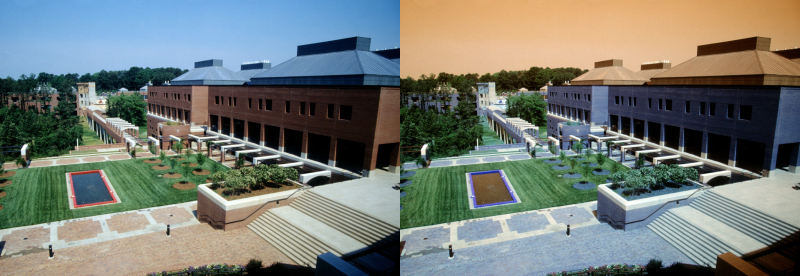

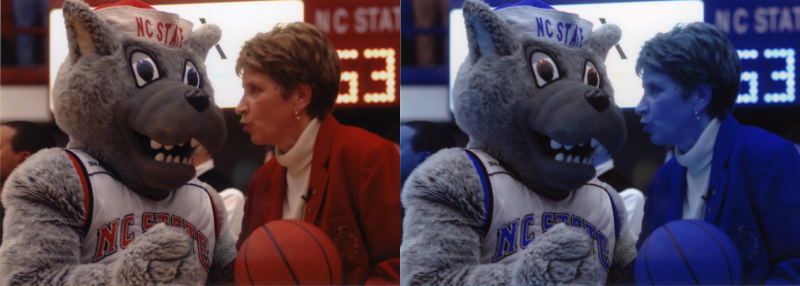

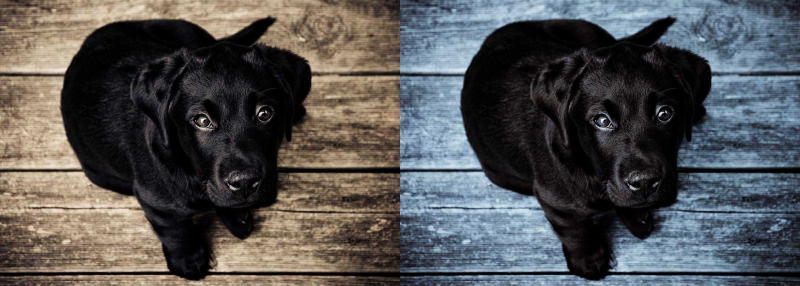

In [2]:
# Membuat list untuk menyimpan url dari beberapa image
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://picsum.photos/id/237/800/571"]

# baca dan tampilkan image, tiap url image dapat disimpan pada list
for url in urls:
    image = io.imread(url)                            # read image
    image = cv.cvtColor(image, cv.COLOR_RGB2BGR)       # skimage baca RGB, cv2 pakai BGR
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)    # resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)     # convert color to RGB
    final_frame = cv.hconcat((image, image_2))         # concatenate image
    cv2_imshow(final_frame)                            # show image
    print('\n')

### Langkah 3 — Melihat Ukuran File Image

resolusi image: tinggi x lebar =  286  x  400


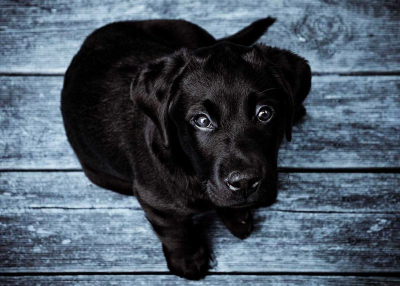

In [3]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi x lebar = ", tinggi, " x ", lebar)
cv2_imshow(image_2)

### Langkah 4 — Akses Pixel: Garis Horizontal Putih di Tengah Image

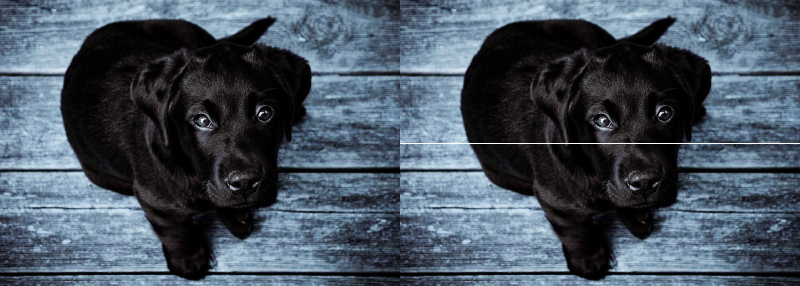

In [4]:
image_3 = image_2.copy()

# membuat garis horizontal ditengah image
for y in range(lebar):
    image_3[int(tinggi/2), y] = [255,255,255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

## PERTANYAAN PRAKTIKUM D2

**1. Mengapa eksekusi kode Python pada modul ini dilakukan menggunakan Google Colab?**

Google Colab menyediakan environment Python siap pakai di cloud (sudah terpasang numpy, pandas, cv2, dll tanpa instalasi manual), gratis akses GPU/TPU, mudah dibagikan/dikolaborasikan lewat link, dan terintegrasi langsung dengan Google Drive serta GitHub sehingga file citra dan notebook mudah diakses dan disimpan tanpa tergantung environment lokal masing-masing mahasiswa yang bisa berbeda-beda (versi Python, OS, dependency).

**2. Kegunaan setiap library pada praktikum langkah ke-delapan? Apakah semua library harus digunakan?**

- `numpy` — manipulasi array/matriks, dasar representasi citra sebagai array piksel, operasi numerik (aljabar linear, dsb).
- `pandas` — manipulasi dan analisis data tabular (dipakai bila ada data pendukung berupa tabel, mis. label/metadata citra).
- `cv2 (OpenCV)` — operasi computer vision: membaca, menampilkan, mengubah ukuran, mengonversi warna, menggambar bentuk pada citra.
- `skimage (scikit-image)` — pemrosesan citra tingkat tinggi, termasuk `io.imread` untuk membaca citra dari file/URL dan `transform` untuk transformasi geometris.
- `matplotlib` — menampilkan citra dalam bentuk plot lengkap dengan sumbu (berguna melihat ukuran piksel), serta visualisasi grafik.

Tidak semua wajib dipakai di setiap sesi — pandas misalnya baru relevan bila mengolah data tabular. Untuk sekadar baca-tampilkan-olah citra, inti yang dipakai adalah numpy, cv2, dan matplotlib/skimage.

**3. `image = cv.resize(image, (0,0), fx=0.5, fy=0.5)` — kegunaan dan pengaruh jika tidak dilakukan?**

Baris ini memperkecil ukuran citra menjadi setengah dari ukuran asli (`fx`/`fy` = skala lebar/tinggi), tanpa menentukan ukuran piksel absolut (karena target size `(0,0)` diabaikan saat `fx`,`fy` diisi). Kegunaannya menghemat memori dan mempercepat proses (concat/tampilkan) terutama untuk citra beresolusi besar. Jika tidak dilakukan, citra tetap dalam ukuran asli — proses jadi lebih berat, dan saat digabung (`hconcat`) dengan citra hasil konversi warna, kedua citra tetap harus berukuran sama sehingga tidak masalah selama keduanya tidak di-resize, hanya saja hasil tampilan jauh lebih besar dan boros resource.

**4. Kegunaan kode `[255,255,255]`?**

`[255,255,255]` adalah nilai piksel RGB (Red, Green, Blue) maksimum di setiap channel pada citra 8-bit, yang menghasilkan warna **putih**. Baris `image_3[int((tinggi)/2), y] = [255,255,255]` mengubah nilai piksel pada baris tengah citra (semua channel warna) menjadi putih, sehingga membentuk garis horizontal putih di tengah citra.

**5. Keterkaitan pixel dan resolusi citra (tinggi/rendah)?**

Pixel adalah satuan terkecil penyusun citra digital, masing-masing menyimpan nilai warna/intensitas. Resolusi adalah jumlah total pixel yang menyusun citra (lebar × tinggi). Semakin tinggi resolusi, semakin banyak pixel yang membentuk citra sehingga detail gambar lebih halus dan tajam, namun ukuran data (memori/penyimpanan) dan waktu pemrosesan juga meningkat. Sebaliknya, resolusi rendah berarti sedikit pixel — citra lebih kasar/blur (kurang detail) tetapi lebih ringan diproses dan disimpan.

## TUGAS PRAKTIKUM D2

**1. Langkah-langkah praktikum sudah dilakukan di atas (Langkah 1-4).**

**2. Garis vertikal dan garis menyilang diagonal pada image keluaran**

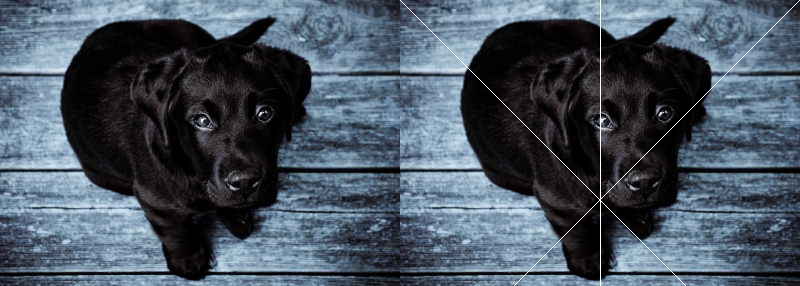

In [5]:
image_4 = image_2.copy()

# garis vertikal ditengah image
for x in range(tinggi):
    image_4[x, int(lebar/2)] = [255,255,255]

# garis diagonal menyilang (dari kedua ujung)
for i in range(min(tinggi, lebar)):
    image_4[i, i] = [255,255,255]
    image_4[i, lebar-1-i] = [255,255,255]

final_frame = cv.hconcat((image_2, image_4))
cv2_imshow(final_frame)

**3. Garis horisontal putih di bagian tengah gambar dengan panjang tertentu**

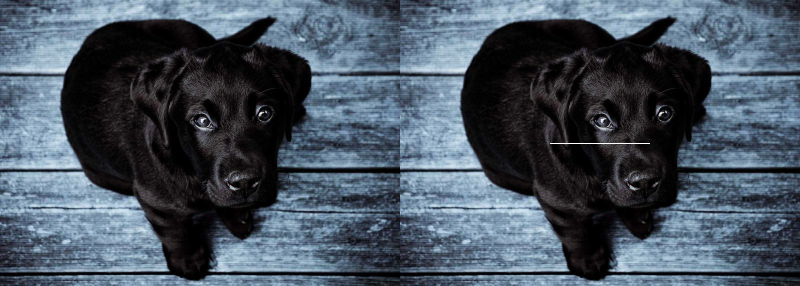

In [6]:
image_5 = image_2.copy()
panjang = 100  # panjang garis dalam pixel
start_x = lebar//2 - panjang//2
for y in range(start_x, start_x + panjang):
    image_5[tinggi//2, y] = [255,255,255]

final_frame = cv.hconcat((image_2, image_5))
cv2_imshow(final_frame)

**4. Kotak menggunakan kumpulan pixel putih di sembarang tempat dalam gambar**

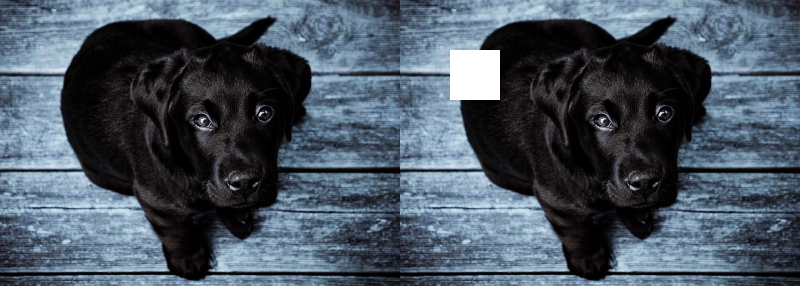

In [7]:
image_6 = image_2.copy()
image_6[50:100, 50:100] = [255,255,255]  # blok pixel putih (kotak) baris 50-100, kolom 50-100

final_frame = cv.hconcat((image_2, image_6))
cv2_imshow(final_frame)